# 📊 Baseline: ResNet50
### HAM10000 · 7-Class Classification · ResNet50 Fine-tuned

**Purpose of this baseline:**
Provides a standard comparison point for the ablation table in the paper.
Trained on the **exact same** 70/15/15 split (random_state=42) with the
same weighted CE loss and same evaluation metrics as v4.

**Key differences from v4:**
- Backbone: **ResNet50** (ImageNet pretrained via timm) — NOT SwinUNet-pretrained
- Architecture: Global Average Pool → MLP head (no FPN, no SE, no mask guidance)
- Training: Standard single-phase fine-tune (no frozen-encoder phase needed)
  because ImageNet features are strong but no segmentation-specific weights to protect

**What this proves in the paper:**
> "Our segmentation-guided Swin-B classifier outperforms standard CNN/ViT baselines
> fine-tuned on the same data, demonstrating the benefit of segmentation pretraining
> and mask-guided feature extraction."

**Expected Macro F1 range:** 0.72–0.80 (literature values for HAM10000)

## STEP 1 — Check GPU

In [7]:
import torch
print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device    : {DEVICE}')

PyTorch version : 2.6.0+cu124
CUDA available  : True
GPU             : NVIDIA GeForce RTX 3050 6GB Laptop GPU
Using device    : cuda


## STEP 2 — Install Dependencies

In [8]:
!pip install -q timm albumentations scikit-learn
print('Done.')

Done.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## STEP 3 — Imports

In [9]:
import os, random, warnings
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

try:
    from torch.amp import GradScaler, autocast
except ImportError:
    from torch.cuda.amp import GradScaler, autocast

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
from PIL import Image
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print(f'albumentations : {A.__version__}')
print(f'timm           : {timm.__version__}')

albumentations : 2.0.8
timm           : 1.0.15


## STEP 4 — Configuration

> **Edit only the paths. Keep all hyperparams identical to v4 for a fair comparison.**

In [10]:
# ── Edit only these paths ─────────────────────────────────────────────────────
IMAGE_DIR    = r'D:\project dataset\cse 7 dataset\HAM10000 classification\HAM10000_images'
METADATA_CSV = r'D:\project dataset\cse 7 dataset\HAM10000 classification\HAM10000_metadata.csv'
SAVE_DIR     = r'D:\arindom classification\Baseline_ResNet50\outputs\baseline_resnet50'
# ──────────────────────────────────────────────────────────────────────────────

# ── Backbone ──────────────────────────────────────────────────────────────────
BACKBONE_NAME  = 'ResNet50'
TIMM_MODEL_ID  = 'resnet50'
FEATURE_DIM    = 2048     # output dim of global average pool for this backbone
DROPOUT        = 0.5

# ── Training — identical to v4 for fair comparison ───────────────────────────
IMG_SIZE        = 224        # identical to v4
BATCH_SIZE      = 32         # identical to v4
NUM_WORKERS     = 0
PIN_MEMORY      = (DEVICE == 'cuda')

# Single-phase training for baselines:
# No frozen-phase needed — backbone is ImageNet pretrained, not task-specific.
# We fine-tune the FULL model from epoch 1 with a moderate LR.
TOTAL_EPOCHS    = 30         # equivalent total budget to v4 Phase 2
LR              = 0.001         # starting LR
LR_MIN          = LR * 0.01  # cosine decay floor

WEIGHT_DECAY    = 1e-4       # identical to v4
PATIENCE        = 10         # identical to v4
LABEL_SMOOTHING = 0.1        # identical to v4

MIXUP_ALPHA     = 0.4        # identical to v4
MIXUP_PROB      = 0.3        # identical to v4

TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.70, 0.15, 0.15

CLASS_NAMES  = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
CLASS_LABELS = {name: idx for idx, name in enumerate(CLASS_NAMES)}
NUM_CLASSES  = len(CLASS_NAMES)

os.makedirs(SAVE_DIR, exist_ok=True)
MODEL_SAVE_PATH = os.path.join(SAVE_DIR, 'baseline_resnet50_best.pth')
REPORT_PATH     = os.path.join(SAVE_DIR, 'classification_report.txt')
CONF_MAT_PATH   = os.path.join(SAVE_DIR, 'confusion_matrix.png')
CURVE_PATH      = os.path.join(SAVE_DIR, 'training_curves.png')

print(f'Backbone      : {BACKBONE_NAME}  ({TIMM_MODEL_ID})')
print(f'Feature dim   : {FEATURE_DIM}')
print(f'Image size    : {IMG_SIZE}x{IMG_SIZE}')
print(f'Batch size    : {BATCH_SIZE}')
print(f'Classes ({NUM_CLASSES})   : {CLASS_NAMES}')
print(f'Epochs        : {TOTAL_EPOCHS}, LR={LR} → {LR_MIN}')
print(f'MixUp         : alpha={MIXUP_ALPHA}, prob={MIXUP_PROB}')
print(f'Save dir      : {SAVE_DIR}')

Backbone      : ResNet50  (resnet50)
Feature dim   : 2048
Image size    : 224x224
Batch size    : 32
Classes (7)   : ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Epochs        : 30, LR=0.001 → 1e-05
MixUp         : alpha=0.4, prob=0.3
Save dir      : D:\arindom classification\Baseline_ResNet50\outputs\baseline_resnet50


## STEP 5 — Load Metadata & Compute Class Weights

In [11]:
df = pd.read_csv(METADATA_CSV)

def image_exists(image_id):
    for ext in ['.jpg', '.jpeg', '.png']:
        if os.path.exists(os.path.join(IMAGE_DIR, image_id + ext)):
            return True
    return False

df = df[df['image_id'].apply(image_exists)].reset_index(drop=True)
df['label'] = df['dx'].map(CLASS_LABELS)
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

print(f'Total valid samples: {len(df)}')
print('\nClass distribution:')
for cls in CLASS_NAMES:
    count = (df['dx'] == cls).sum()
    pct   = 100 * count / len(df)
    bar   = '█' * int(pct / 2)
    print(f'  {cls:6s}: {count:5d}  ({pct:5.1f}%)  {bar}')

class_counts         = np.array([(df['label'] == i).sum() for i in range(NUM_CLASSES)], dtype=np.float32)
class_weights        = 1.0 / (class_counts + 1e-6)
class_weights        = class_weights / class_weights.sum() * NUM_CLASSES
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print('\nClass weights (for loss):')
for cls, w in zip(CLASS_NAMES, class_weights):
    print(f'  {cls:6s}: {w:.4f}')

Total valid samples: 10015

Class distribution:
  akiec :   327  (  3.3%)  █
  bcc   :   514  (  5.1%)  ██
  bkl   :  1099  ( 11.0%)  █████
  df    :   115  (  1.1%)  
  mel   :  1113  ( 11.1%)  █████
  nv    :  6705  ( 66.9%)  █████████████████████████████████
  vasc  :   142  (  1.4%)  

Class weights (for loss):
  akiec : 0.9431
  bcc   : 0.6000
  bkl   : 0.2806
  df    : 2.6816
  mel   : 0.2771
  nv    : 0.0460
  vasc  : 2.1717


## STEP 6 — Train / Val / Test Split

In [12]:
# CRITICAL: random_state=42 — identical to v4 and all ablations
train_df, tmp_df = train_test_split(
    df, test_size=(VAL_RATIO + TEST_RATIO),
    stratify=df['label'], random_state=42
)
val_df, test_df = train_test_split(
    tmp_df, test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
    stratify=tmp_df['label'], random_state=42
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
print('Split identical to v4 (random_state=42) ✅')

Train: 7010 | Val: 1502 | Test: 1503
Split identical to v4 (random_state=42) ✅


## STEP 7 — Dataset & DataLoader

In [13]:
class HAMDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.df        = dataframe
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def _find_image(self, image_id):
        for ext in ['.jpg', '.jpeg', '.png']:
            p = os.path.join(self.image_dir, image_id + ext)
            if os.path.exists(p):
                return p
        raise FileNotFoundError(f'Image not found: {image_id}')

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        path  = self._find_image(row['image_id'])
        image = np.array(Image.open(path).convert('RGB'))
        label = int(row['label'])
        if self.transform:
            image = self.transform(image=image)['image']
        return image, label


_albu_ver = tuple(int(x) for x in A.__version__.split('.')[:2])
if _albu_ver >= (1, 4):
    _coarse  = A.CoarseDropout(num_holes_range=(1, 4), hole_height_range=(16, 32),
                                hole_width_range=(16, 32), p=0.2)
    _elastic = A.ElasticTransform(p=0.2)
else:
    _coarse  = A.CoarseDropout(max_holes=4, max_height=32, max_width=32, p=0.2)
    _elastic = A.ElasticTransform(alpha=120, sigma=120 * 0.05, p=0.2)

# Identical augmentation pipeline to v4 for fair comparison
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Rotate(limit=30, p=0.4),
    _elastic,
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.4),
    A.CLAHE(clip_limit=2.0, p=0.3),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    _coarse,
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

eval_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

train_dataset = HAMDataset(train_df, IMAGE_DIR, train_transform)
val_dataset   = HAMDataset(val_df,   IMAGE_DIR, eval_transform)
test_dataset  = HAMDataset(test_df,  IMAGE_DIR, eval_transform)

# Sqrt WeightedRandomSampler — identical to v4
train_labels       = train_df['label'].values
train_class_counts = np.bincount(train_labels, minlength=NUM_CLASSES).astype(np.float32)
sample_weights     = 1.0 / np.sqrt(train_class_counts[train_labels])
sampler            = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights).float(),
    num_samples=len(train_dataset), replacement=True
)

sqrt_w = 1.0 / np.sqrt(train_class_counts)
max_w  = sqrt_w.max()
print('Sqrt sample weights (identical to v4):')
for cls, cnt, w in zip(CLASS_NAMES, train_class_counts, sqrt_w):
    bar = '█' * int(w / max_w * 20)
    print(f'  {cls:6s}: {int(cnt):4d} → weight {w:.5f}  {bar}')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print(f'\nTrain batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')
print('Sqrt WeightedRandomSampler active')

Sqrt sample weights (identical to v4):
  akiec :  229 → weight 0.06608  ███████████
  bcc   :  360 → weight 0.05270  █████████
  bkl   :  769 → weight 0.03606  ██████
  df    :   81 → weight 0.11111  ████████████████████
  mel   :  779 → weight 0.03583  ██████
  nv    : 4693 → weight 0.01460  ██
  vasc  :   99 → weight 0.10050  ██████████████████

Train batches: 220 | Val: 47 | Test: 47
Sqrt WeightedRandomSampler active


## STEP 8 — Model Architecture: ResNet50

```
Input 224x224x3
      │
      └──► ResNet50 (ImageNet pretrained, timm)
                │
                └──► Global Average Pool → 2048-d feature vector
                              │
                         Dropout(0.5)
                              │
                         FC 2048→512 → ReLU → Dropout(0.3)
                              │
                         FC 512→256 → ReLU → Dropout(0.2)
                              │
                         FC 256→7  (logits)
```

**Why single-phase training for baselines:**
v4 uses a two-phase strategy because Phase 1 protects the segmentation-pretrained
encoder from being destroyed by gradients from an untrained head.
For ResNet50, the backbone is ImageNet-pretrained and does not contain
task-specific segmentation knowledge — so there is no protected knowledge to preserve.
Full fine-tuning from epoch 1 with a moderate LR is the standard approach.

In [14]:
class ResNet50Classifier(nn.Module):
    """
    ResNet50 baseline classifier.
    Backbone: resnet50 with ImageNet pretrained weights from timm.
    Head: GAP → Dropout → FC layers → 7 class logits.
    No FPN, no mask guidance, no SE block.
    """
    def __init__(self, num_classes=7, feature_dim=FEATURE_DIM, dropout=DROPOUT):
        super().__init__()

        # Load backbone with pretrained ImageNet weights
        # num_classes=0 removes the original classifier head, giving raw features
        self.backbone = timm.create_model(
            TIMM_MODEL_ID,
            pretrained=True,
            num_classes=0,          # remove classifier → outputs feature vector
            global_pool='avg'       # global average pool built into timm
        )

        # Verify feature dimension
        with torch.no_grad():
            _dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
            _feat  = self.backbone(_dummy)
            actual_dim = _feat.shape[1]
        print(f'  Backbone feature dim: {actual_dim} (expected {feature_dim})')
        assert actual_dim == feature_dim, (
            f'Feature dim mismatch: got {actual_dim}, expected {feature_dim}. '
            f'Check FEATURE_DIM in config.'
        )

        # MLP classification head
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feature_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )
        self._init_head()

    def _init_head(self):
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def trainable_params(self):
        n     = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.parameters())
        print(f'  Trainable: {n/1e6:.1f}M / {total/1e6:.1f}M  (all params trainable)')

    def forward(self, x):
        feat   = self.backbone(x)   # (B, feature_dim) — GAP done inside backbone
        logits = self.head(feat)    # (B, num_classes)
        return logits


print(f'Building ResNet50 baseline...')
model = ResNet50Classifier(
    num_classes=NUM_CLASSES,
    feature_dim=FEATURE_DIM,
    dropout=DROPOUT
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'Model ready | {total_params/1e6:.1f}M total parameters')
model.trainable_params()

# Shape check
with torch.no_grad():
    _x   = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    _out = model(_x)
    print(f'Output shape: {_out.shape}  (expected [2, {NUM_CLASSES}])')

Building ResNet50 baseline...


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

  Backbone feature dim: 2048 (expected 2048)
Model ready | 24.7M total parameters
  Trainable: 24.7M / 24.7M  (all params trainable)
Output shape: torch.Size([2, 7])  (expected [2, 7])


## STEP 9 — Loss Function

In [10]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor,
    label_smoothing=LABEL_SMOOTHING
)
print(f'Loss : WeightedCrossEntropyLoss (label_smoothing={LABEL_SMOOTHING})')
print(f'Class weights: {[f"{w:.3f}" for w in class_weights]}')

Loss : WeightedCrossEntropyLoss (label_smoothing=0.1)
Class weights: ['0.943', '0.600', '0.281', '2.682', '0.277', '0.046', '2.172']


## STEP 10 — Training & Evaluation Utilities

In [11]:
def mixup_data(images, labels, alpha=MIXUP_ALPHA, device=DEVICE):
    lam          = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index        = torch.randperm(images.size(0), device=device)
    mixed_images = lam * images + (1 - lam) * images[index]
    return mixed_images, labels, labels[index], lam

def mixup_criterion(criterion, logits, label_a, label_b, lam):
    return lam * criterion(logits, label_a) + (1 - lam) * criterion(logits, label_b)

def train_one_epoch(model, loader, optimizer, criterion, scaler, device, use_mixup=True):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc='  Train', leave=False)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        apply_mixup = use_mixup and (random.random() < MIXUP_PROB)
        with autocast(device_type=device):
            if apply_mixup:
                mixed_imgs, label_a, label_b, lam = mixup_data(imgs, labels, device=device)
                logits = model(mixed_imgs)
                loss   = mixup_criterion(criterion, logits, label_a, label_b, lam)
            else:
                logits = model(imgs)
                loss   = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer); scaler.update()
        total_loss += loss.item() * imgs.size(0)
        preds       = logits.argmax(dim=1)
        ref_labels  = labels if not apply_mixup else (label_a if lam >= 0.5 else label_b)
        correct    += (preds == ref_labels).sum().item()
        total      += imgs.size(0)
        pbar.set_postfix(loss=f'{loss.item():.4f}', acc=f'{correct/total:.4f}')
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in tqdm(loader, desc='  Eval ', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        with autocast(device_type=device):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return (total_loss / total, correct / total,
            f1_score(all_labels, all_preds, average='macro', zero_division=0),
            all_preds, all_labels)

def save_curves(history, path, title=''):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(title, fontsize=12, fontweight='bold')
    for ax, key, label in zip(axes, ['loss','acc','macro_f1'],
                               ['Loss','Accuracy','Macro F1']):
        ax.plot(history['train_'+key], label='Train')
        ax.plot(history['val_'+key],   label='Val')
        ax.set_title(label); ax.set_xlabel('Epoch')
        ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'  Curves saved → {path}')

def save_confusion_matrix(y_true, y_pred, class_names, path, title=''):
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'Confusion Matrix — {title}')
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'  Confusion matrix saved → {path}')

print(f'Utilities ready. MixUp: alpha={MIXUP_ALPHA}, prob={MIXUP_PROB}')

Utilities ready. MixUp: alpha=0.4, prob=0.3


## STEP 11 — Training (Single Phase — Full Fine-Tune from Epoch 1)

**Why single-phase for baselines:**
The two-phase strategy in v4 exists to protect segmentation-pretrained encoder
features from being overwritten. ResNet50 is ImageNet-pretrained and
has no such task-specific knowledge to protect. Full fine-tuning with a moderate
learning rate from epoch 1 is the correct standard approach for CNN baselines.

In [12]:
print('=' * 65)
print('  BASELINE: ResNet50 — Full Fine-Tune')
print(f'  LR={LR}, Epochs={TOTAL_EPOCHS}, MixUp prob={MIXUP_PROB}')
print('=' * 65)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=TOTAL_EPOCHS, eta_min=LR_MIN
)
scaler = GradScaler()

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  [],
    'train_macro_f1': [], 'val_macro_f1': []
}
best_val_f1  = 0.0
patience_ctr = 0

for epoch in range(1, TOTAL_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, scaler, DEVICE, use_mixup=True
    )
    vl_loss, vl_acc, vl_f1, _, _ = evaluate(model, val_loader,   criterion, DEVICE)
    _,       tr_acc, tr_f1, _, _ = evaluate(model, train_loader, criterion, DEVICE)

    history['train_loss'].append(tr_loss);    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc);      history['val_acc'].append(vl_acc)
    history['train_macro_f1'].append(tr_f1);  history['val_macro_f1'].append(vl_f1)
    scheduler.step()

    improved = vl_f1 > best_val_f1
    if improved:
        best_val_f1  = vl_f1
        patience_ctr = 0
        torch.save({
            'model_state_dict': model.state_dict(),
            'epoch': epoch,
            'best_val_f1': best_val_f1,
            'backbone': BACKBONE_NAME
        }, MODEL_SAVE_PATH)
    else:
        patience_ctr += 1

    flag = '✅' if improved else '  '
    print(f'  {flag} Ep {epoch:02d}/{TOTAL_EPOCHS} '
          f'| TrLoss {tr_loss:.4f} TrAcc {tr_acc:.4f} TrF1 {tr_f1:.4f} '
          f'| VlLoss {vl_loss:.4f} VlAcc {vl_acc:.4f} VlF1 {vl_f1:.4f}')

    if patience_ctr >= PATIENCE:
        print(f'  Early stopping triggered at epoch {epoch}.')
        print(f'  Val F1 did not improve for {PATIENCE} consecutive epochs.')
        break

print(f'\nTraining complete. Best Val Macro-F1: {best_val_f1:.4f}')
save_curves(history, CURVE_PATH, title=f'Training Curves — ResNet50 Baseline')

  BASELINE: ResNet50 — Full Fine-Tune
  LR=0.001, Epochs=30, MixUp prob=0.3


  ✅ Ep 01/30 | TrLoss 1.6257 TrAcc 0.3873 TrF1 0.3962 | VlLoss 2.3047 VlAcc 0.3342 VlF1 0.2839


  ✅ Ep 02/30 | TrLoss 1.4349 TrAcc 0.3864 TrF1 0.4238 | VlLoss 2.2697 VlAcc 0.3415 VlF1 0.3734


  ✅ Ep 03/30 | TrLoss 1.2680 TrAcc 0.4695 TrF1 0.4937 | VlLoss 2.3494 VlAcc 0.4534 VlF1 0.3936


  ✅ Ep 04/30 | TrLoss 1.1760 TrAcc 0.5983 TrF1 0.6229 | VlLoss 2.0458 VlAcc 0.5266 VlF1 0.4855


...

     Ep 26/30 | TrLoss 0.8167 TrAcc 0.6703 TrF1 0.7491 | VlLoss 1.7590 VlAcc 0.3742 VlF1 0.5597


  ✅ Ep 27/30 | TrLoss 0.8427 TrAcc 0.7740 TrF1 0.8144 | VlLoss 1.7701 VlAcc 0.5739 VlF1 0.6245


     Ep 28/30 | TrLoss 0.8547 TrAcc 0.7548 TrF1 0.8052 | VlLoss 1.7746 VlAcc 0.5220 VlF1 0.5927


     Ep 29/30 | TrLoss 0.8288 TrAcc 0.7204 TrF1 0.7776 | VlLoss 1.7633 VlAcc 0.4334 VlF1 0.5582


     Ep 30/30 | TrLoss 0.8514 TrAcc 0.7288 TrF1 0.7832 | VlLoss 1.7557 VlAcc 0.4647 VlF1 0.5849

Training complete. Best Val Macro-F1: 0.6245
  Curves saved → D:\Baseline_ResNet50\outputs\baseline_resnet50\training_curves.png


## STEP 12 — Test Set Evaluation

In [13]:
ckpt = torch.load(MODEL_SAVE_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
print(f'Loaded best checkpoint: epoch {ckpt["epoch"]}, Val F1={ckpt["best_val_f1"]:.4f}')

test_loss, test_acc, test_f1, test_preds, test_labels = evaluate(
    model, test_loader, criterion, DEVICE
)

print('\n' + '=' * 60)
print(f'  TEST RESULTS — ResNet50 Baseline')
print('=' * 60)
print(f'  Loss      : {test_loss:.4f}')
print(f'  Accuracy  : {test_acc:.4f}  ({test_acc*100:.1f}%)')
print(f'  Macro F1  : {test_f1:.4f}')
print('=' * 60)

report = classification_report(test_labels, test_preds, target_names=CLASS_NAMES, digits=4)
print('\nPer-class report:')
print(report)

with open(REPORT_PATH, 'w') as f:
    f.write(f'Baseline: ResNet50\n')
    f.write(f'Backbone: {TIMM_MODEL_ID} (ImageNet pretrained)\n')
    f.write(f'Test Loss     : {test_loss:.4f}\n')
    f.write(f'Test Accuracy : {test_acc:.4f}\n')
    f.write(f'Test Macro F1 : {test_f1:.4f}\n\n')
    f.write(report)
print(f'Report saved → {REPORT_PATH}')

Loaded best checkpoint: epoch 27, Val F1=0.6245



  TEST RESULTS — ResNet50 Baseline
  Loss      : 1.8303
  Accuracy  : 0.5802  (58.0%)
  Macro F1  : 0.6033

Per-class report:
              precision    recall  f1-score   support

       akiec     0.6364    0.7143    0.6731        49
         bcc     0.8023    0.8961    0.8466        77
         bkl     0.5625    0.8182    0.6667       165
          df     0.0407    0.7059    0.0769        17
         mel     0.4031    0.7844    0.5325       167
          nv     0.9895    0.4682    0.6356      1006
        vasc     0.7308    0.8636    0.7917        22

    accuracy                         0.5802      1503
   macro avg     0.5950    0.7501    0.6033      1503
weighted avg     0.8418    0.5802    0.6356      1503

Report saved → D:\Baseline_ResNet50\outputs\baseline_resnet50\classification_report.txt


## STEP 13 — Confusion Matrix & Per-Class Accuracy

  Confusion matrix saved → D:\Baseline_ResNet50\outputs\baseline_resnet50\confusion_matrix.png


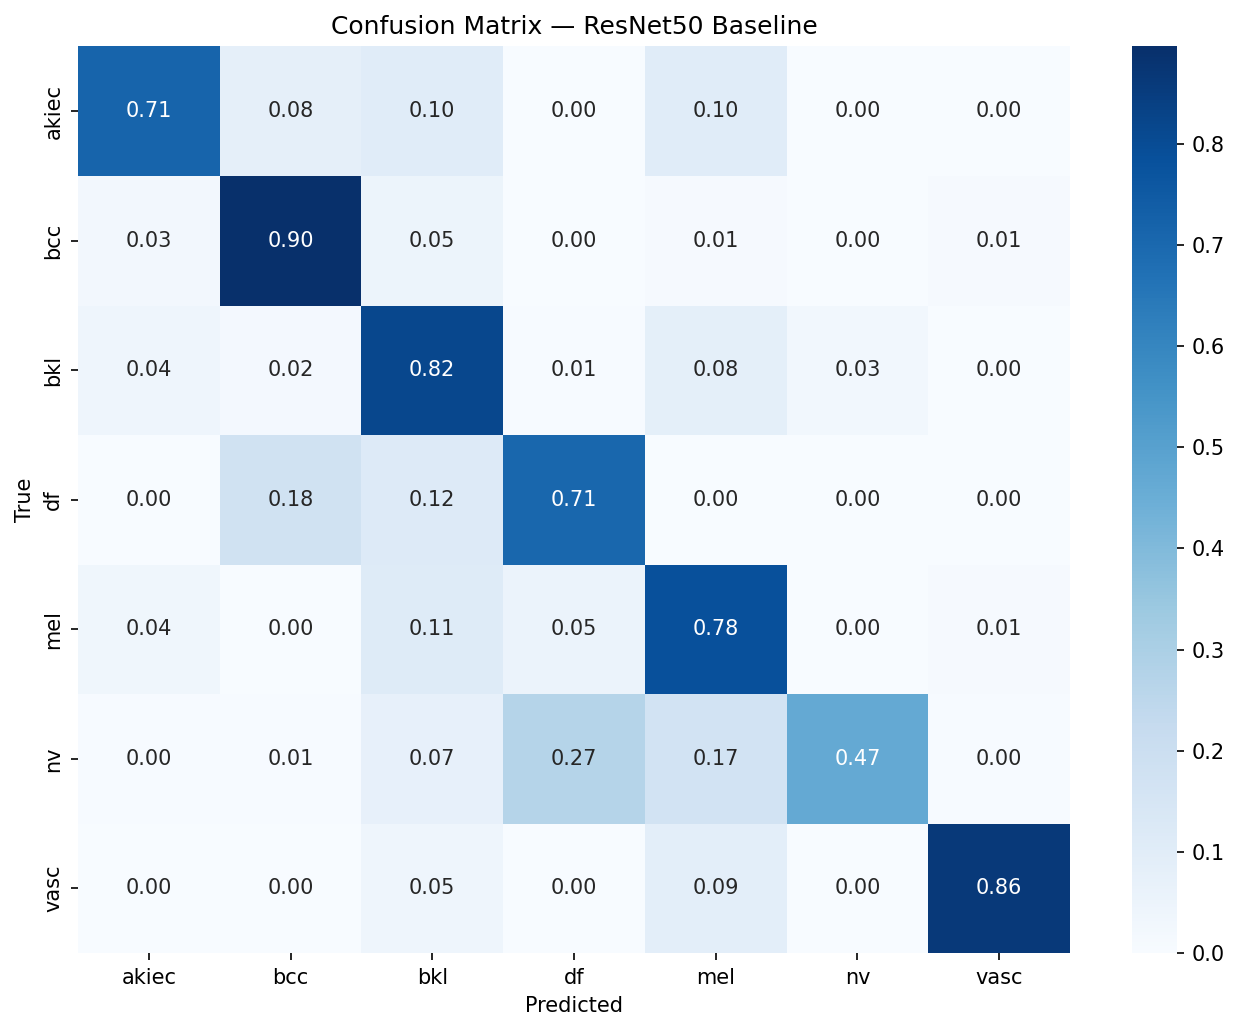

In [14]:
save_confusion_matrix(test_labels, test_preds, CLASS_NAMES,
                       CONF_MAT_PATH, title='ResNet50 Baseline')
try:
    from IPython.display import Image as IPImage, display
    display(IPImage(CONF_MAT_PATH))
except Exception:
    print(f'Open manually: {CONF_MAT_PATH}')

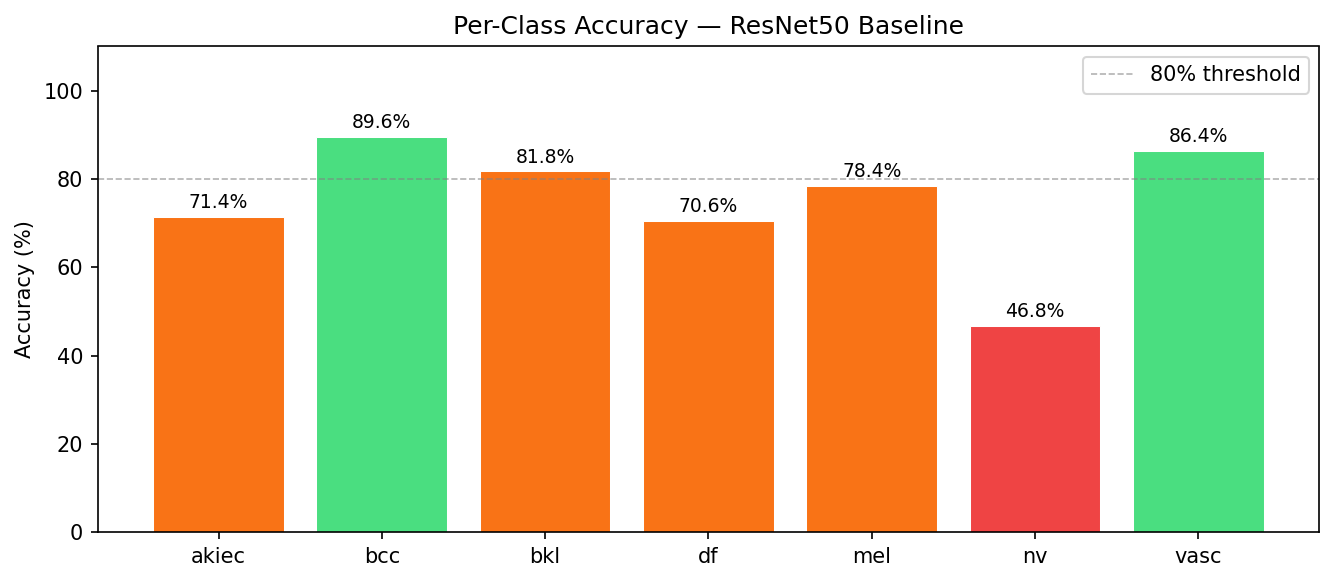


Per-class accuracy:
  akiec :  71.4%  ████████████████████████████
  bcc   :  89.6%  ███████████████████████████████████
  bkl   :  81.8%  ████████████████████████████████
  df    :  70.6%  ████████████████████████████
  mel   :  78.4%  ███████████████████████████████
  nv    :  46.8%  ██████████████████
  vasc  :  86.4%  ██████████████████████████████████


In [15]:
cm = confusion_matrix(test_labels, test_preds)
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#ef4444' if a < 0.7 else '#f97316' if a < 0.85 else '#4ade80'
          for a in per_class_acc]
bars = ax.bar(CLASS_NAMES, per_class_acc * 100, color=colors,
              edgecolor='white', linewidth=0.5)
ax.set_ylim(0, 110)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Class Accuracy — ResNet50 Baseline')
ax.axhline(80, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='80% threshold')
ax.legend()
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
bar_path = CONF_MAT_PATH.replace('confusion_matrix', 'per_class_acc')
plt.savefig(bar_path, dpi=150, bbox_inches='tight')
plt.close()

try:
    from IPython.display import Image as IPImage, display
    display(IPImage(bar_path))
except Exception:
    pass

print('\nPer-class accuracy:')
for cls, acc in zip(CLASS_NAMES, per_class_acc):
    print(f'  {cls:6s}: {acc*100:5.1f}%  ' + '█' * int(acc * 40))

## STEP 14 — Summary & Comparison Table

In [16]:
print('╔══════════════════════════════════════════════════════════════════╗')
print('║  BASELINE: ResNet50                                                ║')
print('╠══════════════════════════════════════════════════════════════════╣')
print(f'║  Backbone      : {BACKBONE_NAME} (ImageNet pretrained)           ║')
print(f'║  Parameters    : {sum(p.numel() for p in model.parameters())/1e6:.1f}M                                    ║')
print(f'║  Training      : Single-phase, {TOTAL_EPOCHS} epochs max            ║')
print(f'║  Test Loss     : {test_loss:.4f}                                       ║')
print(f'║  Test Accuracy : {test_acc:.4f}  ({test_acc*100:.1f}%)                          ║')
print(f'║  Test Macro F1 : {test_f1:.4f}                                       ║')
print('╠══════════════════════════════════════════════════════════════════╣')
print('║  COMPARISON TABLE (fill in after all experiments)                ║')
print('║  Model                          | Macro F1 | ΔvBaseline           ║')
print('║  ResNet50 baseline              | TBD      | 0.0 (reference)      ║')
print('║  EfficientNet-B4 baseline       | TBD      | TBD                  ║')
print('║  Ablation-C (sqrt+mixup only)   | TBD      | TBD                  ║')
print('║  Ablation-A (SE only)           | TBD      | TBD                  ║')
print('║  Ablation-B (mask only)         | TBD      | TBD                  ║')
print('║  v4 FULL (mask + SE)            | TBD      | TBD                  ║')
print('╚══════════════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════════════╗
║  BASELINE: ResNet50                                                ║
╠══════════════════════════════════════════════════════════════════╣
║  Backbone      : ResNet50 (ImageNet pretrained)           ║
║  Parameters    : 24.7M                                    ║
║  Training      : Single-phase, 30 epochs max            ║
║  Test Loss     : 1.8303                                       ║
║  Test Accuracy : 0.5802  (58.0%)                          ║
║  Test Macro F1 : 0.6033                                       ║
╠══════════════════════════════════════════════════════════════════╣
║  COMPARISON TABLE (fill in after all experiments)                ║
║  Model                          | Macro F1 | ΔvBaseline           ║
║  ResNet50 baseline              | TBD      | 0.0 (reference)      ║
║  EfficientNet-B4 baseline       | TBD      | TBD                  ║
║  Ablation-C (sqrt+mixup only)   | TBD      | TBD               

## EXS Computation (Grad-CAM proxy) — paste and run after Cell 29

In [15]:
# ══════════════════════════════════════════════════════════════════
# EXS COMPUTATION FOR ResNet50 BASELINE
# Paste this as a NEW CELL at the END of Baseline_ResNet50.ipynb
# (after Cell 29 — after the existing summary box)
#
# HOW IT WORKS:
# ResNet50 has no spatial FPN feature map like v5, so we use Grad-CAM
# as an attention proxy. Grad-CAM produces a spatial heatmap showing
# which regions the model attended to when making each prediction.
# We then compute IoU(heatmap, mask) and entropy(heatmap) to get EXS.
#
# NO RETRAINING NEEDED. This cell loads the saved checkpoint,
# runs inference on the test set, and computes EXS.
# ══════════════════════════════════════════════════════════════════

import math
import os
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Fallbacks for running this cell after a kernel restart.
DEVICE = globals().get('DEVICE', 'cuda' if torch.cuda.is_available() else 'cpu')
IMAGE_DIR = globals().get('IMAGE_DIR', r'D:\project dataset\cse 7 dataset\HAM10000 classification\HAM10000_images')
SAVE_DIR = globals().get('SAVE_DIR', r'D:\arindom classification\Baseline_ResNet50\outputs\baseline_resnet50')
MODEL_SAVE_PATH = globals().get('MODEL_SAVE_PATH', os.path.join(SAVE_DIR, 'baseline_resnet50_best.pth'))

if not os.path.exists(IMAGE_DIR):
    alt_image_dir = r'D:\project dataset\cse 7 dataset\HAM10000 classification\HAM10000_images'
    if os.path.exists(alt_image_dir):
        IMAGE_DIR = alt_image_dir
    else:
        raise FileNotFoundError(f'Image directory not found: {IMAGE_DIR}')

if not os.path.exists(MODEL_SAVE_PATH):
    alt_ckpt = r'D:\arindom classification\Baseline_ResNet50\outputs\baseline_resnet50\baseline_resnet50_best.pth'
    if os.path.exists(alt_ckpt):
        MODEL_SAVE_PATH = alt_ckpt
        SAVE_DIR = os.path.dirname(alt_ckpt)
    else:
        raise FileNotFoundError(f'Checkpoint not found: {MODEL_SAVE_PATH}')

for required_name in ['model', 'test_df', 'eval_transform']:
    if required_name not in globals():
        raise RuntimeError(f'Missing {required_name}. Run the earlier model/data/transform cells first; retraining is not needed.')

# ── Step 1: Reload model and best checkpoint ──────────────────────────────────
ckpt = torch.load(MODEL_SAVE_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f'Checkpoint loaded: epoch={ckpt["epoch"]}  ValF1={ckpt["best_val_f1"]:.4f}')

# ── Step 2: Identify the Grad-CAM target layer ───────────────────────────────
# For ResNet50: last convolutional layer before global average pooling.
# This is layer4[-1].conv3 — the deepest spatial feature map (7×7, 2048ch).
# We verified this by inspecting: list(model.backbone.named_modules())
target_layer = [model.backbone.layer4[-1]]
print(f'Grad-CAM target layer: model.backbone.layer4[-1]')
print(f'  (Last residual block of ResNet50 — 7×7 spatial, 2048 channels)')

# ── Step 3: Load segmentation masks for test set ─────────────────────────────
# We need the binary masks to compare against Grad-CAM attention.
# Masks are stored in MASK_DIR (same as v5 experiments).
MASK_DIR = r'D:\project dataset\cse 7 dataset\HAM10000 classification\mask'
# If your masks are in a different location, update the path above.

def find_mask_path(image_id, mask_dir):
    for s in ['_segmentation.png', '_segmentation.jpg', '.png', '.jpg']:
        p = os.path.join(mask_dir, image_id + s)
        if os.path.exists(p):
            return p
    return None

# ── Step 4: EXS computation loop ──────────────────────────────────────────────
print('\nComputing EXS for ResNet50 baseline via Grad-CAM proxy...')

iou_list, ent_list, valid_count = [], [], 0

cam_engine = GradCAM(model=model, target_layers=target_layer)

for idx in range(len(test_df)):
    row      = test_df.iloc[idx]
    image_id = row['image_id']
    label    = int(row['label'])

    # Load mask — skip samples without masks
    mask_path = find_mask_path(image_id, MASK_DIR)
    if mask_path is None:
        continue

    mask = np.array(Image.open(mask_path).convert('L'), dtype=np.float32)
    mask = (mask > 127).astype(np.float32)  # binarise
    mask_t = torch.from_numpy(mask).unsqueeze(0).unsqueeze(0)  # (1,1,H,W)

    # Load and preprocess image
    for ext in ['.jpg', '.jpeg', '.png']:
        img_path = os.path.join(IMAGE_DIR, image_id + ext)
        if os.path.exists(img_path):
            break
    image = np.array(Image.open(img_path).convert('RGB'))
    aug   = eval_transform(image=image)
    img_t = aug['image'].unsqueeze(0).to(DEVICE)  # (1,3,224,224)

    # Grad-CAM → attention map (224×224, values in [0,1])
    targets  = [ClassifierOutputTarget(label)]
    cam_map  = cam_engine(input_tensor=img_t, targets=targets)  # (1,224,224)
    attn     = torch.from_numpy(cam_map[0]).unsqueeze(0).unsqueeze(0)  # (1,1,224,224)

    # Resize mask to match attention map size
    H_a, W_a = attn.shape[2], attn.shape[3]
    mask_r   = F.interpolate(mask_t, size=(H_a, W_a), mode='bilinear', align_corners=False)

    # Per-sample min-max normalise attention (already in [0,1] from Grad-CAM, but ensure)
    a_flat = attn.view(1, -1)
    a_norm = (a_flat - a_flat.min()) / (a_flat.max() - a_flat.min() + 1e-6)
    attn_2d = a_norm.view(1, 1, H_a, W_a)

    # IoU term
    inter = (attn_2d * mask_r).sum()
    union = attn_2d.sum() + mask_r.sum() - inter
    iou_s = (inter / (union + 1e-6)).item()
    iou_list.append(iou_s)

    # Entropy term (normalised by log(N))
    N       = H_a * W_a
    af_c    = torch.clamp(a_norm, min=1e-6)
    p       = af_c / af_c.sum()
    ent_raw = -(p * torch.log(p)).sum().item()
    ent_n   = ent_raw / math.log(N)
    ent_list.append(ent_n)

    valid_count += 1
    if valid_count % 100 == 0:
        print(f'  Processed {valid_count} samples...')

cam_engine.__exit__(None, None, None)

# ── Step 5: Report EXS ────────────────────────────────────────────────────────
mean_iou   = float(np.mean(iou_list))
mean_ent   = float(np.mean(ent_list))
mean_focus = 1.0 - mean_ent
exs        = 0.5 * mean_iou + 0.5 * mean_focus


print('  EXS RESULTS — ResNet50 Baseline (Grad-CAM proxy)')

print(f'  Samples with masks: {valid_count} / {len(test_df)}')
print(f'  IoU(attn, mask)  : {mean_iou:.4f}  ← spatial correctness')
print(f'  Entropy (norm)   : {mean_ent:.4f}  ← diffuseness (lower=better)')
print(f'  Focus quality    : {mean_focus:.4f}  ← 1 − entropy')
print(f'  EXS              : {exs:.4f}  ← composite score')
print()
print('  Compare with v5 (ACL-trained):')
print(f'  ResNet50  EXS = {exs:.4f}  IoU = {mean_iou:.4f}')
print(f'  v5 (ours) EXS = 0.5185    IoU = 0.8966')
print(f'  XS = {0.5185 - exs:+.4f}  Δ IoU = {0.8966 - mean_iou:+.4f}')

# Save
import json as _j
result = {'model': 'ResNet50', 'exs': round(exs,4),
          'iou': round(mean_iou,4), 'focus': round(mean_focus,4),
          'entropy': round(mean_ent,4), 'n_valid': valid_count}
with open(os.path.join(SAVE_DIR, 'resnet50_exs.json'), 'w') as fh:
    _j.dump(result, fh, indent=2)
print(f'\nSaved → {os.path.join(SAVE_DIR, "resnet50_exs.json")}')


Checkpoint loaded: epoch=27  ValF1=0.6245
Grad-CAM target layer: model.backbone.layer4[-1]
  (Last residual block of ResNet50 — 7×7 spatial, 2048 channels)

Computing EXS for ResNet50 baseline via Grad-CAM proxy...
  Processed 100 samples...
  Processed 200 samples...
  Processed 300 samples...
  Processed 400 samples...
  Processed 500 samples...
  Processed 600 samples...
  Processed 700 samples...
  Processed 800 samples...
  Processed 900 samples...
  Processed 1000 samples...
  Processed 1100 samples...
  Processed 1200 samples...
  Processed 1300 samples...
  Processed 1400 samples...
  Processed 1500 samples...
  EXS RESULTS — ResNet50 Baseline (Grad-CAM proxy)
  Samples with masks: 1503 / 1503
  IoU(attn, mask)  : 0.2178  ← spatial correctness
  Entropy (norm)   : 0.9437  ← diffuseness (lower=better)
  Focus quality    : 0.0563  ← 1 − entropy
  EXS              : 0.1370  ← composite score

  Compare with v5 (ACL-trained):
  ResNet50  EXS = 0.1370  IoU = 0.2178
  v5 (ours) EXS =